# Crop Flood Damage Assessment — Pipeline Walkthrough

**VIT Tech-a-thon · Problem Statement 6**

This notebook walks the prescribed sequence step by step, on the real data, so each stage can
be inspected rather than taken on trust. It mirrors `src/fcda/pipeline.py`.

| Step | Image pipeline | Tabular pipeline |
|---|---|---|
| 1 | Load image dataset | Load CSV dataset |
| 2 | Preprocessing | Preprocessing |
| 3 | **Leakage checks** | **Leakage checks** |
| 4 | CLAHE | — |
| 5 | Split + 10-fold CV | Split + 10-fold CV |
| 6 | **GAN augmentation (train only)** | **SMOTE (train only)** |
| 7 | Initial training | Initial training |
| 8 | Over/under-fit detection | Over/under-fit detection |
| 9 | Correction + retrain | Correction + retrain |
| 10 | Final test evaluation | Final test evaluation |

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

from fcda import SEVERITY_CLASSES
DATA = Path.cwd().parent / "data"
print("severity classes:", SEVERITY_CLASSES)
print("device:", "mps" if torch.backends.mps.is_available() else "cpu")

severity classes: ('Healthy', 'Mild', 'Moderate', 'Severe')
device: mps


## Step 1 — Load the image dataset

ETCI-2021 Sentinel-1 SAR over Bangladesh. Each tile has **two acquisitions** — pre-monsoon (2017-03-14) and monsoon flood (2017-06-06) — with VV, VH, a flood mask and a permanent-water mask at both dates.

In [2]:
from fcda.data.etci import label_pool, natural_prior, build_index

pool = label_pool(DATA, progress=False)
print(f"pool: {len(pool)} tiles with a complete pre/post pair")
print("natural class prior:", natural_prior(pool))

records = build_index(DATA, 400, progress=False)
labels = np.array([r.label for r in records])
print("\ntier T2_small (Healthy capped at 45%):",
      {SEVERITY_CLASSES[i]: int((labels == i).sum()) for i in range(4)})

pool: 2032 tiles with a complete pre/post pair
natural class prior: {'Healthy': 0.8686, 'Mild': 0.0807, 'Moderate': 0.0408, 'Severe': 0.0098}

tier T2_small (Healthy capped at 45%): {'Healthy': 180, 'Mild': 117, 'Moderate': 83, 'Severe': 20}


### What a tile actually looks like

Water is specular — it reflects the radar away from the sensor, so flooded ground reads **dark** in SAR amplitude. That is the signal the whole system rests on.

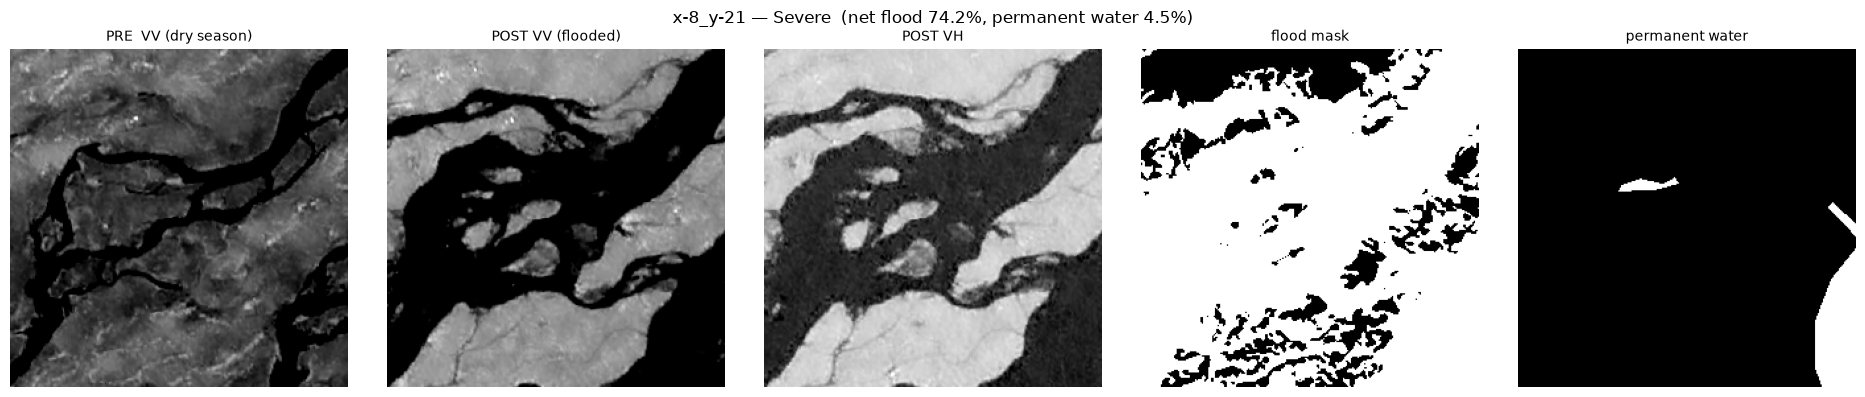

In [3]:
from fcda.data.etci import load_planes
from fcda.data.severity import severity_from_masks

worst = sorted(records, key=lambda r: -r.net_flood_fraction)[0]
p = load_planes(DATA, worst.tile_id)
sev = severity_from_masks(p["post_flood"], p["post_water_body"])

fig, ax = plt.subplots(1, 5, figsize=(19, 4))
for a, (k, t) in zip(ax, [("pre_vv", "PRE  VV (dry season)"), ("post_vv", "POST VV (flooded)"),
                          ("post_vh", "POST VH"), ("post_flood", "flood mask"),
                          ("post_water_body", "permanent water")]):
    a.imshow(p[k], cmap="gray"); a.set_title(t, fontsize=10); a.axis("off")
fig.suptitle(f"{worst.tile_id} — {sev.name}  (net flood {sev.net_flood_fraction:.1%}, "
             f"permanent water {sev.permanent_water_fraction:.1%})", fontsize=12)
plt.tight_layout(); plt.show()

### How severity is derived

`severity = bin(net flood fraction)` where **net flood = flood mask − permanent water**, binned
at 2% / 10% / 33%.

The 33% boundary is anchored on Indian NDRF/SDRF relief practice, where a crop loss of 33% or
more is the threshold for input-subsidy compensation. Subtracting permanent water matters
because **a tile containing a river is not a damaged tile**.

In [4]:
from fcda.data.severity import DEFAULT_THRESHOLDS, THRESHOLD_RATIONALE
for k, v in THRESHOLD_RATIONALE.items():
    print(f"{k:14s} {v}")

# Proof that a river alone is never scored as damage
river = np.zeros((100, 100), np.uint8); river[:, 40:70] = 255   # 30% of the tile is water
print("\nriver-only tile ->", severity_from_masks(river, river).name,
      "| net:", severity_from_masks(river, river).net_flood_fraction)

healthy_max    Below 2% net inundation is treated as speckle/edge effect, not damage.
mild_max       2-10% is localised waterlogging at field margins.
moderate_max   10-33% is partial inundation below the Indian NDRF/SDRF 33% crop-loss compensation threshold.
severe         33% or more net inundation aligns with the NDRF/SDRF threshold at which crop loss qualifies for input-subsidy relief.

river-only tile -> Healthy | net: 0.0


## Step 2 — Preprocessing

VV, VH and their ratio are stacked into three channels. The ratio is a genuine derived band: open water suppresses both polarisations, but not equally.

In [5]:
from fcda.preprocess.transforms import build_transform
from fcda.data.etci import _stack_sar

train_tf = build_transform(train=True, use_clahe=True, seed=0)
eval_tf  = build_transform(train=False, use_clahe=True, seed=0)
print("train:", train_tf)
print("eval :", eval_tf)

raw = _stack_sar(p["post_vv"], p["post_vh"], 256)
print("\nstacked:", raw.shape, "| channels: VV, VH, VV/VH ratio")

train: Compose(['CLAHE(clip_limit=2.0, tile_grid=8)', 'RandomFlip(p=0.5)', 'SpeckleNoise(strength=0.1, p=0.3)', 'Normalize()'])
eval : Compose(['CLAHE(clip_limit=2.0, tile_grid=8)', 'Normalize()'])

stacked: (3, 256, 256) | channels: VV, VH, VV/VH ratio


## Step 4 — CLAHE

SAR amplitude sits in a narrow dark band and is dominated by speckle. Global equalisation would amplify the noise; CLAHE lifts local contrast at the flood boundary, which is the part the segmentation head has to get right. It is applied to the polarisation channels only — the ratio channel is physical and is left alone.

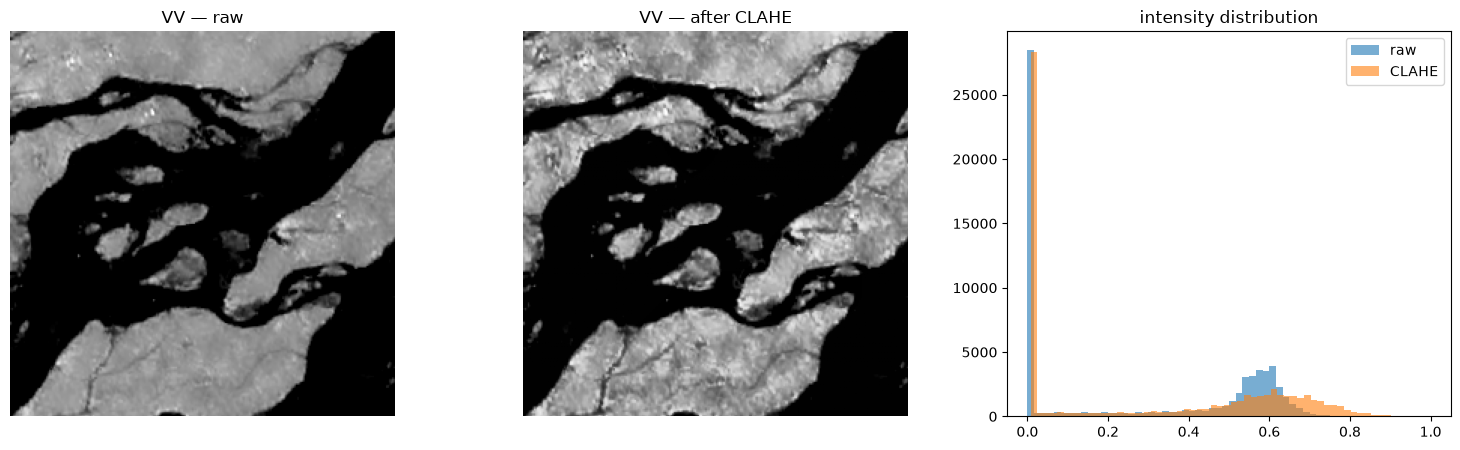

In [6]:
from fcda.preprocess.clahe import CLAHE
enhanced = CLAHE()(raw.copy())

fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
ax[0].imshow(raw[0], cmap="gray"); ax[0].set_title("VV — raw"); ax[0].axis("off")
ax[1].imshow(enhanced[0], cmap="gray"); ax[1].set_title("VV — after CLAHE"); ax[1].axis("off")
ax[2].hist(raw[0].ravel(), bins=60, alpha=0.6, label="raw")
ax[2].hist(enhanced[0].ravel(), bins=60, alpha=0.6, label="CLAHE")
ax[2].legend(); ax[2].set_title("intensity distribution")
plt.tight_layout(); plt.show()

## Step 3 — Leakage checks

Three families, as prescribed. On the tabular side this produces a **real finding**, not a drill.

In [7]:
from fcda.preprocess.leakage import average_hash, hamming

h_pre, h_post = average_hash(p["pre_vv"]), average_hash(p["post_vv"])
other = load_planes(DATA, records[7].tile_id)
print("perceptual hash distance")
print(f"  same location, pre vs post : {hamming(h_pre, h_post):2d}")
print(f"  different tile             : {hamming(h_post, average_hash(other['post_vv'])):2d}")
print("\nA small distance across splits would mean the model can memorise instead of learn.")

perceptual hash distance
  same location, pre vs post :  3
  different tile             : 36

A small distance across splits would mean the model can memorise instead of learn.


## Steps 1–3 on the tabular side, and the leakage trap

The label is derived from the yield anomaly, and `YIELD = PRODUCTION / AREA`. Leaving those columns in gives a near-perfect, completely worthless model.

In [8]:
from fcda.data.india_agri import build_tabular_dataset, FEATURE_COLS, LEAKY_COLS
from fcda.preprocess.leakage import check_target_leakage, check_suspicious_features, merge_reports

df = build_tabular_dataset(DATA / "india_crops.csv")
print(f"{len(df):,} rows | {df.district.nunique()} districts | {df.crop.nunique()} crops")

counts = df.label.value_counts().sort_index()
print("class balance:", {SEVERITY_CLASSES[i]: int(counts[i]) for i in counts.index},
      f"-> imbalance {counts.max()/counts.min():.1f}:1")

report = merge_reports(check_target_leakage(df, "label", known_leaky=LEAKY_COLS),
                       check_suspicious_features(df[FEATURE_COLS + ["label"]], "label"))
print("\n" + report.render())
print("\nAction: drop", [c for c in LEAKY_COLS if c in df.columns])

34,342 rows | 310 districts | 23 crops
class balance: {'Healthy': 20405, 'Mild': 6226, 'Moderate': 5844, 'Severe': 1867} -> imbalance 10.9:1

[CRITICAL] target_leakage: columns used to construct the label are present and must be dropped before modelling (6 items)

Action: drop ['yield', 'production', 'yield_z', 'yield_mean', 'yield_std', 'label_name']


## Step 5 — Split, grouped by district

The group is the district. The same district in train and test would let the model memorise a district's yield level instead of learning a damage signal.

In [9]:
from fcda.splits import grouped_stratified_split, class_balance

X = df[FEATURE_COLS].to_numpy(float); y = df.label.to_numpy()
split = grouped_stratified_split(y, df.district.to_numpy(), seed=42)
print("sizes:", split.sizes())
for n, idx in [("train", split.train), ("val", split.val), ("test", split.test)]:
    print(f"  {n:5s}", class_balance(y, idx))

overlap = set(df.district.to_numpy()[split.train]) & set(df.district.to_numpy()[split.test])
print("\ndistricts shared between train and test:", len(overlap))

sizes: {'train': 24041, 'val': 5156, 'test': 5145}
  train {0: 14260, 1: 4329, 2: 4186, 3: 1266}
  val   {0: 3127, 1: 896, 2: 804, 3: 329}
  test  {0: 3018, 1: 1001, 2: 854, 3: 272}

districts shared between train and test: 0


## Step 6 — SMOTE, on the training split only

This ordering is the entire point. SMOTE interpolates between neighbours; run before the split, a test row can be interpolated into a training row and the score becomes a measure of memorisation.

SMOTE[SMOTE]: 24041 -> 57040 rows (+32999 synthetic); {0: 14260, 1: 4329, 2: 4186, 3: 1266} -> {0: 14260, 1: 14260, 2: 14260, 3: 14260}

val and test unchanged: 5156 / 5145  ->  5156 / 5145


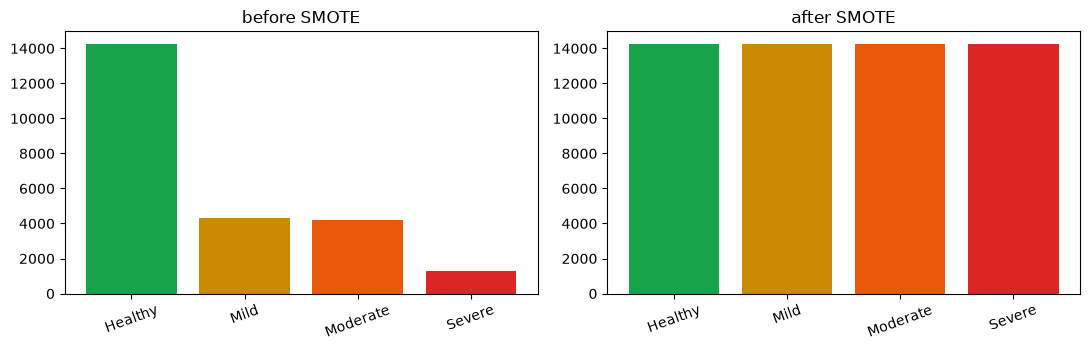

In [10]:
from fcda.augment.smote import balance_training_split

n_val, n_test = len(split.val), len(split.test)
sm = balance_training_split(X[split.train], y[split.train], seed=42)
print(sm.summary())
print(f"\nval and test unchanged: {n_val} / {n_test}  ->  {len(split.val)} / {len(split.test)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for a, (d, t) in zip(ax, [(sm.before, "before SMOTE"), (sm.after, "after SMOTE")]):
    a.bar([SEVERITY_CLASSES[k] for k in d], list(d.values()),
          color=["#16a34a", "#ca8a04", "#ea580c", "#dc2626"])
    a.set_title(t); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## Step 6 (image) — GAN augmentation, on the training split only

A conditional DCGAN generating **image and mask together**, conditioned on severity. Unconditional would mostly produce Healthy tiles — exactly the wrong thing for an imbalanced problem.

In [11]:
from fcda.augment.gan import deficit_counts
train_labels = labels[:int(len(labels) * 0.7)]
print("training-split counts:", {SEVERITY_CLASSES[i]: int((train_labels == i).sum()) for i in range(4)})
print("synthetic tiles needed to balance:", {SEVERITY_CLASSES[k]: v
      for k, v in deficit_counts(train_labels).items()})
print("\nSee reports/results.json for the GAN actually trained during the benchmark run.")

training-split counts: {'Healthy': 180, 'Mild': 40, 'Moderate': 40, 'Severe': 20}
synthetic tiles needed to balance: {'Healthy': 0, 'Mild': 140, 'Moderate': 140, 'Severe': 160}

See reports/results.json for the GAN actually trained during the benchmark run.


## Steps 7–10 — Train, diagnose, correct, evaluate

The diagnostic uses the generalisation gap **and** the learning-curve slope, so 'converged and poor' is distinguished from 'still climbing'.

In [12]:
from fcda.train.diagnostics import diagnose
from fcda.train.correction import plan_correction, TrainConfig

cfg = TrainConfig()
scenarios = {
    "classic overfit":   ([.5,.7,.85,.92,.96], [.45,.52,.55,.54,.53]),
    "underfit, climbing":([.2,.25,.3,.34,.38], [.19,.24,.29,.33,.37]),
    "healthy":           ([.5,.62,.70,.74,.77],[.48,.60,.67,.71,.73]),
}
for name, (tr, va) in scenarios.items():
    d = diagnose(tr, va); c = plan_correction(d, cfg)
    print(f"{name:20s} -> {d.status.value:9s}  {d.reason}")
    print(f"{'':20s}    {c.describe()}\n")

classic overfit      -> OVERFIT    train macro-F1 exceeds validation by 0.410 (threshold 0.15)
                        Regularisation increase (dropout, weight decay, augmentation, label smoothing) with earlier stopping (weight_decay: 0.0001 -> 0.001, dropout: 0.1 -> 0.4, augment_strength: 1.0 -> 2.0, patience: 5 -> 3, label_smoothing: 0.0 -> 0.1)

underfit, climbing   -> UNDERFIT   validation still improving at +0.0450/epoch and only reached 0.370
                        Extended schedule with a higher learning rate (still improving) (lr: 0.0003 -> 0.0006, epochs: 12 -> 18, patience: 5 -> 8)

healthy              -> OK         gap 0.040 within tolerance and validation reached 0.730
                        No correction: fit is within tolerance; no retraining needed



## The five hybrids

All five end in the same decoder and the same head, so the comparison isolates the encoder.

In [13]:
from fcda.models.registry import MODELS, build_model, is_temporal, DISPLAY_NAMES

rows = []
for n in MODELS:
    m = build_model(n, pretrained=False); m.eval()
    x = torch.randn(1, 2, 3, 256, 256) if is_temporal(n) else torch.randn(1, 3, 256, 256)
    with torch.no_grad(): seg, cls = m(x)
    rows.append({"hybrid": DISPLAY_NAMES[n], "params (M)": round(m.n_params()/1e6, 1),
                 "temporal": is_temporal(n), "seg out": tuple(seg.shape[-2:]),
                 "classes": cls.shape[-1]})
pd.DataFrame(rows)

,hybrid,params (M),temporal,seg out,classes
0,YOLO12 + U-Net,9.8,False,"(256, 256)",4
1,ResNet + U-Net,24.4,False,"(256, 256)",4
2,EfficientNet + Attention,5.7,False,"(256, 256)",4
3,Swin Transformer + U-Net,31.9,False,"(256, 256)",4
4,CNN + LSTM,9.0,True,"(256, 256)",4


## Benchmark results

Loaded from the actual training run.

In [14]:
res_path = Path.cwd().parent / "reports" / "results.json"
if res_path.exists():
    from fcda.eval.report import comparison_table, per_class_table
    from IPython.display import Markdown, display
    results = json.loads(res_path.read_text())
    display(Markdown(comparison_table(results)))
    display(Markdown("**Per-class F1**\n\n" + per_class_table(results)))
else:
    print("Run `make train` first.")

Run `make train` first.


In [15]:
sc = Path.cwd().parent / "reports" / "scaling_log.json"
if sc.exists():
    s = json.loads(sc.read_text())
    display(pd.DataFrame(s["measurements"]))
    print("machine:", s["machine"])
    print("stopped because:", s["stopped_because"])

## Fusion — from pixels to rupees

A segmentation model reports pixels. A district officer needs hectares, tonnes and which crop was standing in the water.

In [16]:
from fcda.fusion import estimate_district_loss, fuse

for e in estimate_district_loss(df, "Durg", "Severe", flooded_fraction=0.18, top_n=4):
    print(f"{e.crop:14s} {e.affected_area_kha:7.2f} kha affected | "
          f"{e.production_loss_tonnes:10.1f} t | Rs {e.indicative_value_inr/1e7:7.2f} crore")

print("\nfusion:", fuse("Moderate", 0.81, 0.22, tabular_label=3, tabular_confidence=0.66)["note"])

RICE            147.68 kha affected |   143950.1 t | Rs  314.24 crore
CHICKPEA         39.46 kha affected |    23147.1 t | Rs  125.92 crore
MINOR PULSES     23.02 kha affected |     7290.8 t | Rs   18.23 crore
OILSEEDS         19.41 kha affected |     8695.7 t | Rs   21.74 crore

fusion: district history indicates Severe; severity escalated one level from Moderate


---

## Limitations

1. Severity is **derived from flood extent**, not measured agronomic damage — ETCI has no
   crop-damage ground truth.
2. Only **20 Severe tiles** exist in the whole pool (0.98% natural prior), so Severe-class F1 is
   noisy by construction.
3. Tiers cap Healthy at 45% to make the benchmark usable; the natural prior is reported alongside.
4. Training geography is the Ganges–Brahmaputra delta; cross-region transfer is untested.
5. Rupee figures use assumed loss coefficients, exposed as parameters rather than fitted.

Full detail: `docs/literature_review.md`, `docs/objective.md`, `docs/sequence_compliance.md`.